# Initial Exploration of (Dis)Aggregation Dynamics

Fitz Koch  
2026-05-04

In [2]:
import sys, os
from pathlib import Path

_project_root = Path.cwd()
while not (_project_root / "src").exists():
    _project_root = _project_root.parent
os.chdir(_project_root) 

In [3]:
# library imports
from itertools import product


# package imports
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from numba import jit
from IPython.display import display, Markdown
from odeintw import odeintw
import matplotlib.colors as mcolors


# package global configs
plt.style.use(["ggplot"])

In [4]:
# Define page width
IMG_WIDTH = 6
IMG_HEIGHT = 6

# Master Equations

The master equation is:

$$
\frac{\mathrm{d} c_{k}}{\mathrm{d} t }  = \frac{1}{2} \sum _{i+j=k} K_{ij}c_{i}c_{j} - c_{k}\sum _{j \geq  1}K_{kj}c_{j} + \sum _{j\geq  1} F_{kj} c_{j+k} - \frac{1}{2} c_{k} \sum _{i+j=k}F_{ij}
$$

Where $$
K_{ij} = \begin{cases}
150^{2}ij + 150(i_+j) + 4 \\
ij
\end{cases}
$$

Another way to think of this is that there are $N$ quantities that can vary independently, where $N = \sum_k c_k(0) \cdot k$

# Aggregation Alone

In [5]:
def build_kernel(kernel_rule, N: int):
    K = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(N+1):
            K[i, j] = kernel_rule(i, j)
    return K
build_kernel(lambda i, j : 2, 3)

array([[2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.]])

In [6]:
def aggregation_dot(x, t, K, N):
    dx = np.zeros_like(x)
    for k in range(1, N + 1):
        for i in range(1, k):
            j = k - i
            if i + j <= N: 
                dx[k] += 0.5 * K[i, j] * x[i] * x[j]
        for j in range(1, N+1 - k):
            dx[k] -= x[k] * K[k, j] * x[j]
    return dx

In [7]:
def aggregate_meq(
    kernel_rule,
    N,
    t_length=5,
    t_steps=100,
    ax=None,
    title_string="",
    label=True,
):
    t_vec = np.linspace(0, t_length, t_steps * (t_length + 1))
    x_0 = np.zeros(N + 1, dtype=float)  # shape: cluster size
    x_0[1] = N  # initially all monomers
    K = build_kernel(kernel_rule, N + 1)
    G = lambda x, t: aggregation_dot(x, t, K, N)
    x_path = odeint(G, x_0, t_vec)

    mass = np.dot(np.arange(N + 1), x_path.T)
    if not np.allclose(mass, mass[0]):
        print(f"Mass not conserved: {mass}")

    # product plot
    if ax is not None:
        total_time = t_length * t_steps
        step_scale = total_time // 5
        for t in np.arange(0, total_time, step_scale):
            ax.plot(
                range(N + 1),
                x_path[t],
                marker="o",
                ls="--",
                label=rf"$t = {t // t_steps:}$",
            )
            if label:
                ax.set_ylabel("Count")
                ax.set_xlabel("Custer Size")
    return t_vec, x_path

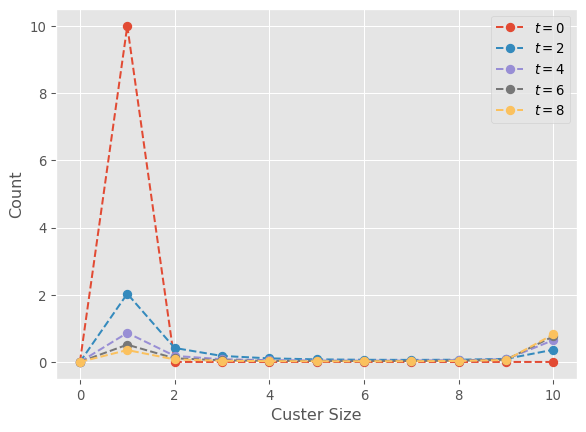

In [8]:
fig, ax = plt.subplots()
aggregate_meq(
    kernel_rule=lambda i, j: .1 * i * j,
    N=10,
    t_length=10,
    t_steps=100,
    ax=ax,
    title_string="",
    label=True,
)
plt.legend()
plt.show()

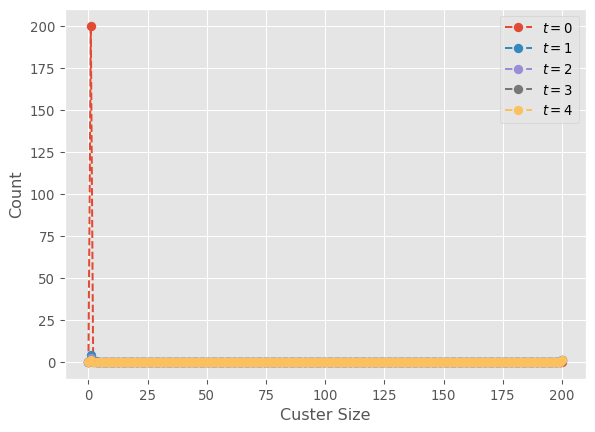

In [9]:
fig, ax = plt.subplots()
aggregate_meq(
    kernel_rule=lambda i, j: .1 * i * j,
    N=200,
    t_length=5,
    t_steps=100,
    ax=ax,
    title_string="",
    label=True,
)
plt.legend()
plt.show()

This works, but… on reflection it’s not quite doing what we want; it’s not giving us a sense of how the probability is shifting, just giving us the exact counts…

## Stochastic Aggregation (aborted)

In [10]:
def twoD_aggregation_dot(x, t, K, N):
    dx = 0 * x
    concentrations = np.sum(x, axis=0)  # still just summing, though...
    outflow_transition = np.zeros(N, N)
    inflow_transition = np.zeros(N, N)
    for size, count in np.ndindex(x.shape):
        outflow_transition[size, count] = count * sum(
            [K[size, j] * concentrations[j] for j in range(1, N)]
        )
        pairs = [(i, k - i) for i in range(1, k)]
        inflow_transition[size, count] = 0.5 * sum(
            [K[size, j] * concentrations[i] * concentrations for i, j in pairs]
        )

In [11]:
def twoD_integrate_aggregation(kernel_rule, N, axes=None, t_length=5, t_steps=100):
    t_vec = np.linspace(0, t_length, t_steps * (t_length +1))
    x_0 = np.zeros((N+1, N+1), dtype=float) # shape: cluster size k, size count c, where value = probability
    x_0[1][N] = 1  # initially all monomers
    K = build_kernel(kernel_rule, N+1)
    G = lambda x, t : aggregation_dot(x, t, K, N ) 
    x_path = odeintw(G, x_0, t_vec)

# Aggregation and Fragmentation in One

Parameterize the kernel dictionaries

In [12]:
def delta(a, b):
    return 1 if a==b else 0 

kernel_dictionary = {
    "product":  lambda i, j: i * j,
    "r_prod": lambda i, j : 1 / (i *j) if i*j > 0 else 0,
    "sum": lambda i,j : i + j ,
    "constant" : lambda i,j : 1,
    "chipping_1": lambda i, j : delta(i, 1) + delta(j, 1),
    "chipping_5": lambda i, j : delta(i, 5) + delta(j, 5),
}

In order to keep track of the cost, we need to monitor both the *number* of interventions that are actually applied, and the *size* of those interventions.

In [13]:
def agg_frag_dot(x, t, K, F, N):
    dx = np.zeros_like(x)
    cost_number = 0
    cost_amount = 0
    for k in range(1, N + 1):
        for i in range(1, k):
            j = k - i
            dx[k] += 0.5 * K[i, j] * x[i] * x[j] ## agg inflow 
            frag_out = 0.5 * x[k] * F[i,j] 
            dx[k] -= frag_out  ## frag outflow 
            cost_number += 1 / (1 + np.exp(-frag_out * 1000))
            cost_amount += frag_out * min(i, j)
        for j in range(1, N+1 - k):
            dx[k] -= x[k] * K[k, j] * x[j] ## agg outflow 
            frag_in = F[k, j] * x[k + j]  ## frag inflow
            dx[k] += frag_in
            cost_number += 1 / (1 + np.exp(-frag_in * 1000))
            cost_amount += frag_in * min(j, k)
    dx[N+1] = cost_number # number of frag 
    dx[N+2] = cost_amount # amount of frag 
    return dx

In [14]:
def agg_frag_meq(
    agg_rule,
    frag_rule,
    N,
    t_length=5,
    t_steps=100,
    initial_conditions={1 : 1 }
):
    t_vec = np.linspace(0, t_length, t_steps * (t_length + 1))
    # x shape: first N+1 for cluster size, then info storage
    x_0 = np.zeros(N + 1 + 2, dtype=float)
    # setup, initially all monomers, in current version. by probability
    for size, prop in initial_conditions.items():
        x_0[size] = prop
    agg_kernel, agg_multiplier = agg_rule
    frg_kernel, frg_multiplier = frag_rule

    K = build_kernel(kernel_dictionary[agg_kernel], N + 1)
    K *= agg_multiplier
    F = build_kernel(kernel_dictionary[frg_kernel], N + 1)
    F *= frg_multiplier

    G = lambda x, t: agg_frag_dot(x, t, K, F, N)
    x_path = odeint(G, x_0, t_vec)
    x_path, cost_path = x_path[:, :-2], x_path[:, -2:]

    mass = np.dot(np.arange(N + 1), x_path.T)
    if not np.allclose(mass, mass[0]):
        print(f"Mass not conserved: {mass}")

    return t_vec, x_path, cost_path

In [15]:
def heatmap_cluster_sizes(ax, t_length, x_path, title_string="", shown_steps=5 ):
    if ax is not None:
        sns.heatmap(
            x_path.T,
            ax=ax,
            cmap="viridis",
            norm=mcolors.LogNorm(vmin=1e-6, vmax=1),
        )
        ax.set_ylabel("Cluster Size")
        ax.set_xticks(np.linspace(0, x_path.shape[0], shown_steps))
        ax.set_xticklabels(np.round(np.linspace(0, t_length, shown_steps), 1))
        ax.set_title(title_string)

Try a couple of these:

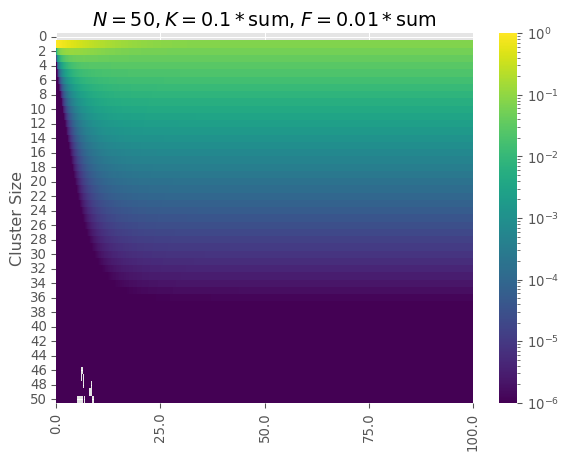

In [16]:
fig, ax = plt.subplots()
agg_kernel = "sum"
agg_multiplier = .1 
frg_multiplier = .01
frg_kernel = "sum"
agg_rule = (agg_kernel, agg_multiplier)
frag_rule = (frg_kernel, frg_multiplier)
N = 50
t_length = 100
t_steps = 100
axes = ax
title_string = rf"$N={N}, K={agg_multiplier}*${agg_kernel}, $F={frg_multiplier}*${frg_kernel}"


t_vec, x_path, cost_path = agg_frag_meq(
    agg_rule=agg_rule,
    frag_rule=frag_rule,
    N=N,
    t_length=t_length,
    t_steps=t_steps,
)
heatmap_cluster_sizes(ax, t_length, x_path, title_string=title_string)
plt.show()

# Calculations

There are three additional things we want to do/know: 1. Did we reach a steady state? \* We can see if the last $\tilde{n}$ iterations are all similar (np.allclose) \* we could even then iterate through and see *when* we reached the steady state 2. How much probability for different definitions of ‘domination’ at end: \* more than 60% \* more than 70% 3. What’s the gradient of the cost in the steady state? \* can do just the smallest value 4. work from different initial conditions

In [17]:
def steady_state(x_path, t_steps=100, step=10, atol=1e-3):
    length = len(x_path)
    if not np.allclose(x_path[-1], x_path[-20:], atol=atol):
        return 0
    for count in range(1, int(0.5 * length), t_steps):
        if not np.allclose(x_path[-1], x_path[-count], atol=atol):
            return (length - count)
        if np.allclose(x_path[-1], x_path[count], atol=atol):
            return count
    return 0
s_idx = steady_state(x_path)
print(s_idx)

4501

In [18]:
def calculate_domination(x_path, cutoff: float, sizes=None):
    N = x_path.shape[1] - 1
    if sizes is None:
        sizes = np.arange(N + 1)
    min_dom_idx = int(N * cutoff)
    dominating_prob = x_path[-1, min_dom_idx:]
    dominating_masses = dominating_prob * sizes[min_dom_idx:]
    return dominating_masses.sum()


calculate_domination(x_path, 0.6)

np.float64(0.0009525699243500924)

In [19]:
def steady_state_slope(cost_path, t_vec, s_idx):
    if s_idx: 
        grad = np.gradient(cost_path[:, 1], t_vec)
        steady_grad = grad[s_idx:].mean()
        return steady_grad
    return 0

steady_state_slope(cost_path, t_vec, s_idx)

np.float64(0.2267623291789237)

In [20]:
initial_condition_dict = {
    "All Monomer": {1 : 1},
    "Di_Monomer" : {1 : .5, 2: .25},
    "First 10": {i: 1/(i*10) for i in range(1, 11)}
}

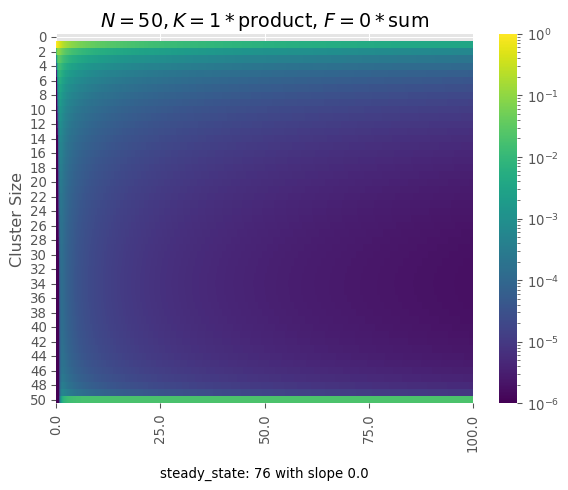

7699 0.0 0.9921574644179032

In [21]:
fig, ax = plt.subplots()
agg_kernel = "product"
agg_multiplier = 1
frg_multiplier = 0
frg_kernel = "sum"
agg_rule = (agg_kernel, agg_multiplier)
frag_rule = (frg_kernel, frg_multiplier)
N = 50
t_length = 100
t_steps = 100
title_string = rf"$N={N}, K={agg_multiplier}*${agg_kernel}, $F={frg_multiplier}*${frg_kernel}"

t_vec, x_path, cost_path = agg_frag_meq(
    agg_rule=agg_rule,
    frag_rule=frag_rule,
    N=N,
    t_length=t_length,
    t_steps=t_steps,
)
heatmap_cluster_sizes(ax, t_length, x_path, title_string=title_string)

sizes = np.arange(N + 1)
s_idx = steady_state(x_path)
s_slope = steady_state_slope(cost_path, t_vec, s_idx)
dom = calculate_domination(x_path, 0.6, sizes)
ax.text(
    0.5,
    -0.2,
    f"steady_state: {s_idx // t_length} with slope {s_slope}",
    transform=ax.transAxes,
    ha="center",
)
plt.show()

print(s_idx, s_slope, dom)

9599 0.0 7.514998732075187e-05

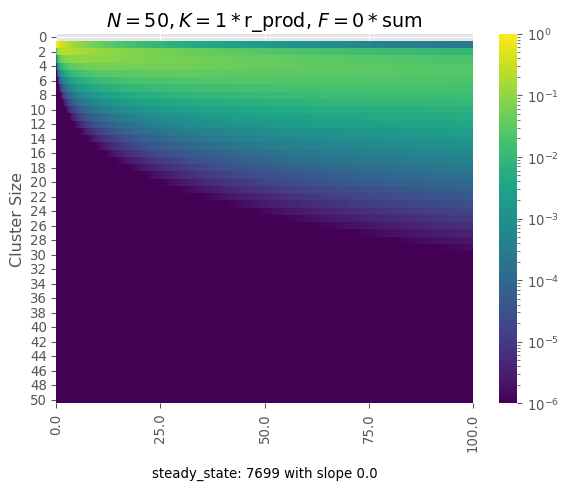

In [22]:
fig, ax = plt.subplots()
agg_kernel = "r_prod"
agg_multiplier = 1
frg_multiplier = 0
frg_kernel = "sum"
agg_rule = (agg_kernel, agg_multiplier)
frag_rule = (frg_kernel, frg_multiplier)
N = 50
t_length = 100
t_steps = 100
title_string = rf"$N={N}, K={agg_multiplier}*${agg_kernel}, $F={frg_multiplier}*${frg_kernel}"


t_vec, x_path, cost_path = agg_frag_meq(
    agg_rule=agg_rule,
    frag_rule=frag_rule,
    N=N,
    t_length=t_length,
    t_steps=t_steps,
)
heatmap_cluster_sizes(ax, t_length, x_path, title_string=title_string)
ax.text(0.5, -0.2, f"steady_state: {s_idx} with slope {s_slope}", transform=ax.transAxes, ha='center')

s_idx = steady_state(x_path)
s_slope = steady_state_slope(cost_path, t_vec, s_idx)
dom = calculate_domination(x_path, .6)
print(s_idx, s_slope, dom)
plt.show()

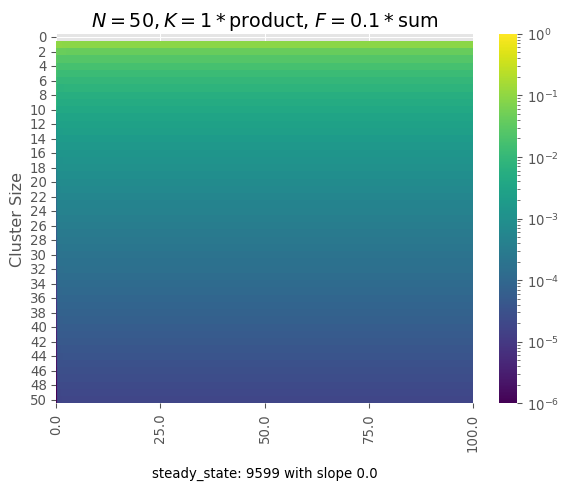

301 7.576648687830119 0.0561603514039577

In [23]:
fig, ax = plt.subplots()
agg_kernel = "product"
agg_multiplier = 1
frg_multiplier = 0.1
frg_kernel = "sum"
agg_rule = (agg_kernel, agg_multiplier)
frag_rule = (frg_kernel, frg_multiplier)
N = 50
t_length = 100
t_steps = 100
title_string = rf"$N={N}, K={agg_multiplier}*${agg_kernel}, $F={frg_multiplier}*${frg_kernel}"
init_cond = initial_condition_dict["First 10"]


t_vec, x_path, cost_path = agg_frag_meq(
    agg_rule=agg_rule,
    frag_rule=frag_rule,
    N=N,
    t_length=t_length,
    t_steps=t_steps,
    initial_conditions=init_cond,
)
heatmap_cluster_sizes(ax, t_length, x_path, title_string=title_string)
ax.text(
    0.5,
    -0.2,
    f"steady_state: {s_idx} with slope {s_slope}",
    transform=ax.transAxes,
    ha="center",
)

plt.show()
s_idx = steady_state(x_path)
s_slope = steady_state_slope(cost_path, t_vec, s_idx)
dom = calculate_domination(x_path, 0.6)
print(s_idx, s_slope, dom)

# Grid Search

For nomenclature:

-   $K$ is the matrix of aggregation rates
-   $F$ is the matrix of fragmentation rates
-   $T$ is the total time the simulation runs
-   $N$ is the total amount of mass, conserved across all steps. We normalize this to one, but we still have a discrete number of clusters, so it effects how fine grained the simulation can be.
-   $t \in \{ 1 \dots T \}$ is the variable for how much clock time – not integration steps – have passed
-   $\vec{\mathbf{c}_{t}} \equiv \{ c_{1}(t), c_{2}(t), \dots,  c_{k}(t) \}$ is the vector of all cluster sizes at a given time $t$
-   $C \equiv \{ \vec{\mathbf{c}}_{0}, \dots, \vec{\mathbf{c}}_{T}   \}$ is what our integration returns; the vector of the cluster distributions at each time step.
-   $\alpha$ scales the aggregation matrix
-   $\beta$ scales the fragmentation matrix
-   $s \equiv \min(t) \mid C_{s}=C_{i}\quad \forall i>s$
-   $\kappa_{t} = .5\sum F_{ij}c_{k}(t) \times \min(i, j) + \sum F_{kj} c_{k+j}(t) \times \min(k,j)$; the total number of mass units that are *removed* from other masses via fragmentation at any given time step
-   $\dot{\kappa}$ is the *gradient of the cost*, and $\dot{\kappa}_{s}$ is the gradient at the steady state

$$
g_{x}= \frac{\sum_{{k > xN}} c_{k}(t)}{\sum c_{k(t)}}
$$ The proportion of clusters of size greater than $x$, where $x$ is a float indicating the threshold for what we consider a dominating cluster.

finished block 0
finished block 1
finished block 2
finished block 3
finished block 4
finished block 5
finished block 6
finished block 7
finished block 8

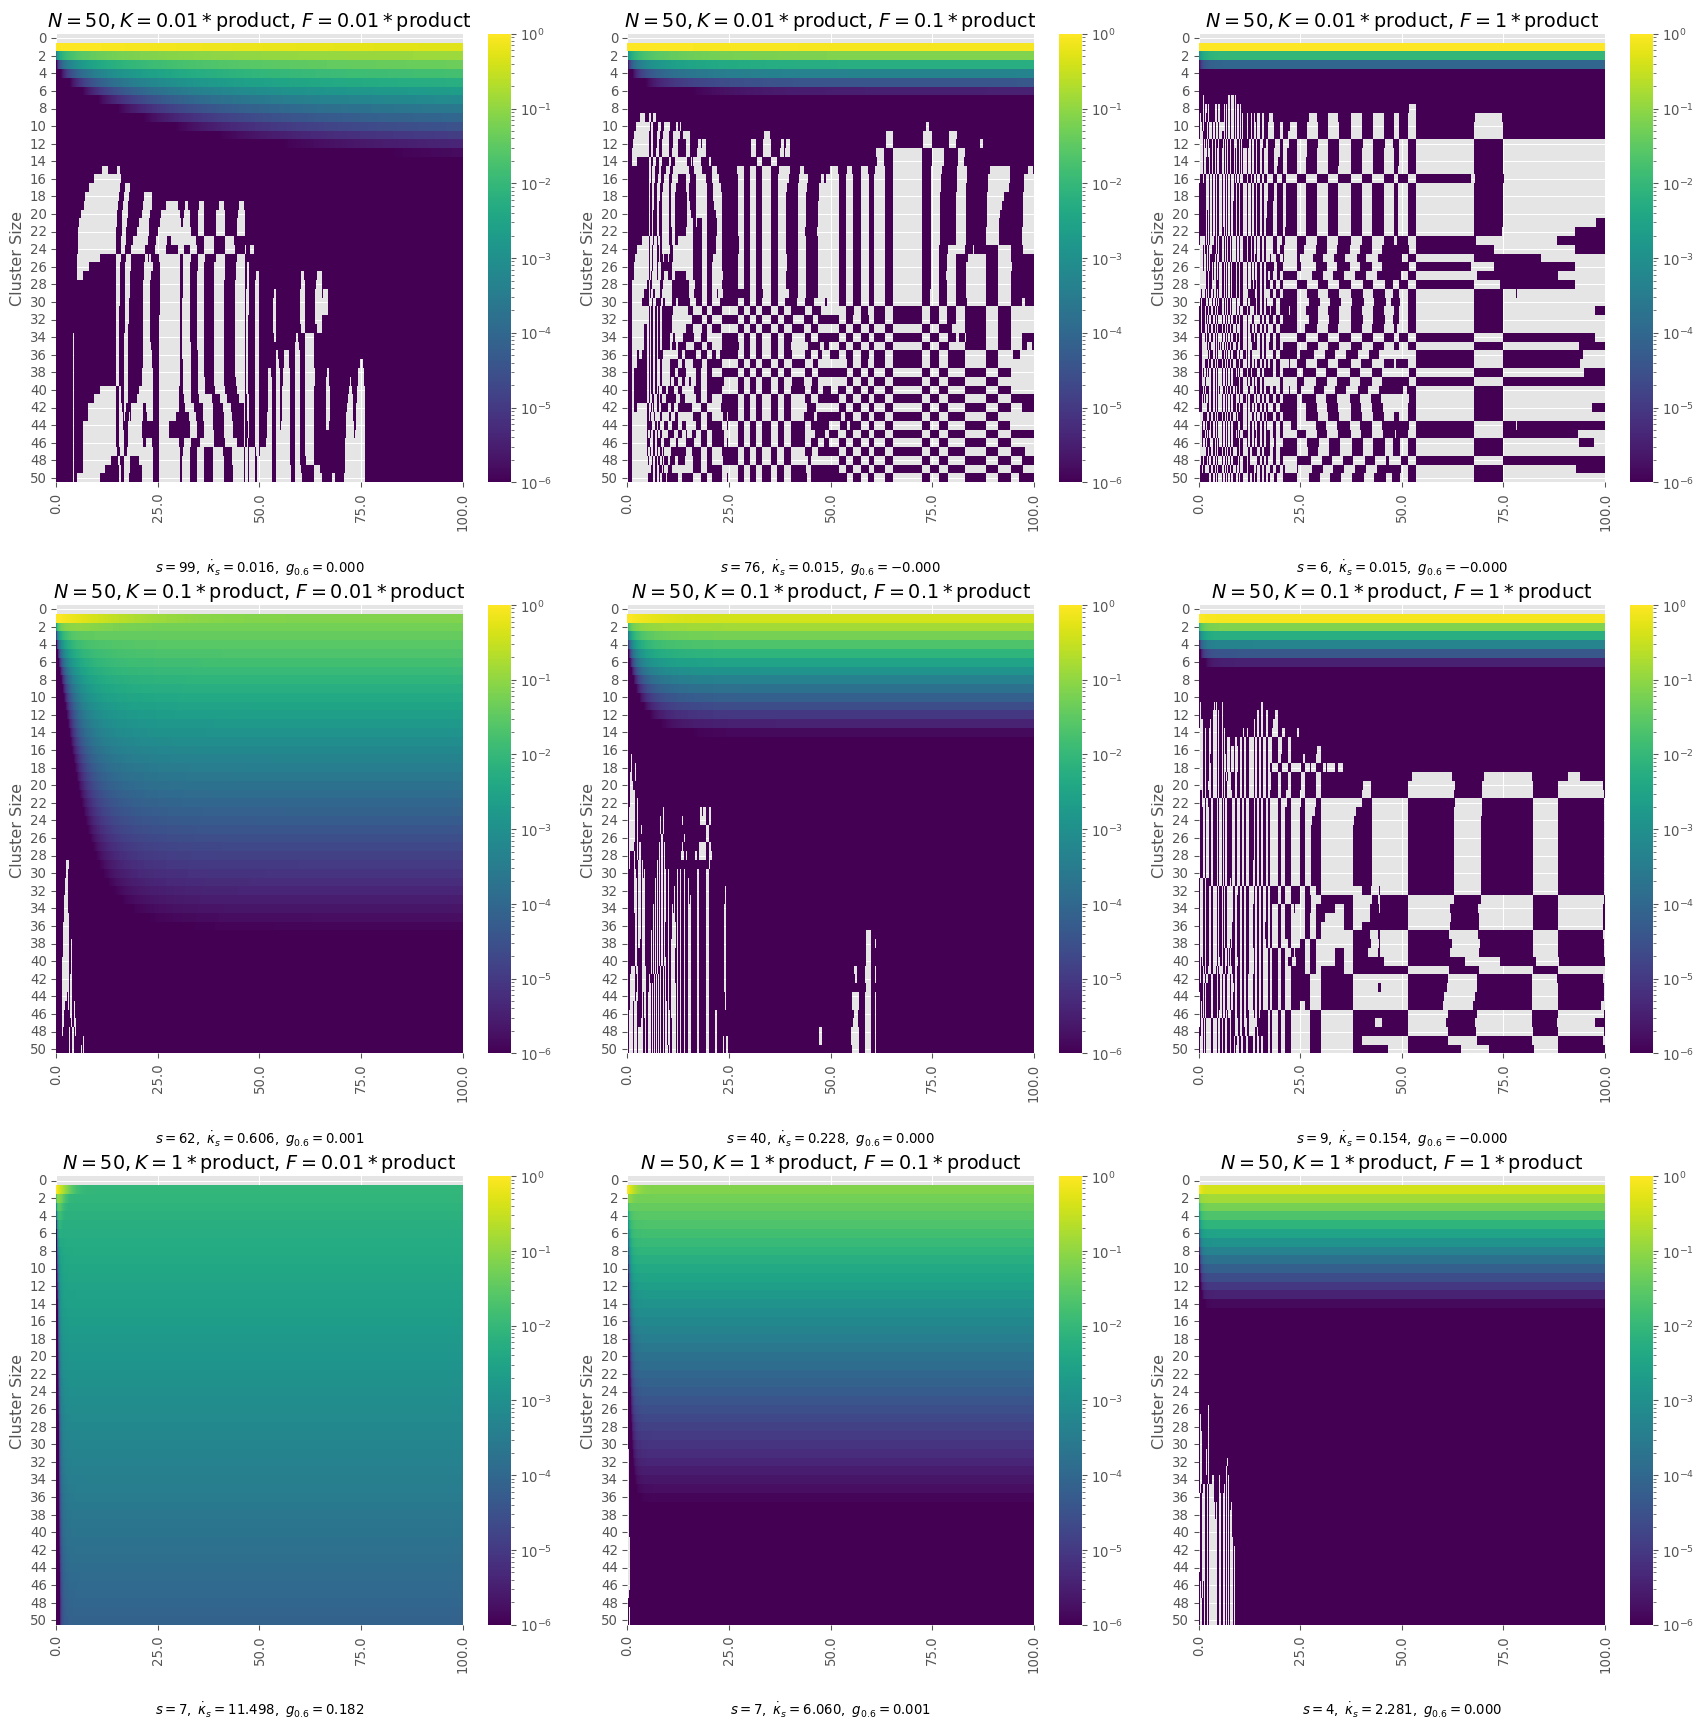

In [24]:
initial_conds = ["All Monomer"]
agg_kernels = ["product"]
agg_multipliers = [0.01, 0.1, 1]
frg_kernels = ["product"]
frg_multipliers = [0.01, 0.1, 1]
init_conds = ["All Monomer", "First 10"]
count = (
    len(agg_kernels)
    * len(frg_kernels)
    * len(agg_multipliers)
    * len(frg_multipliers)
    * len(initial_conds)
)

results_dict = {
    "agg_kernel": [],
    "agg_multiplier": [],
    "frg_kernel": [],
    "frg_multiplier": [],
    "N": [],
    "t_length": [],
    "s_idx": [],
    "s_slope": [],
    "init_cond": [],
    "dom60": [],
    "dom80": [],
}

ncols = 3
nrows = (count + 1) // ncols
sizes = np.arange(N + 1)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(IMG_WIDTH * ncols, IMG_HEIGHT * nrows),
)
axes = axes.flatten()
for i, (
    agg_kernel,
    agg_multiplier,
    frg_kernel,
    frg_multiplier,
    init_cond,
) in enumerate(
    product(
        agg_kernels,
        agg_multipliers,
        frg_kernels,
        frg_multipliers,
        initial_conds,
    )
):
    agg_rule = (agg_kernel, agg_multiplier)
    frag_rule = (frg_kernel, frg_multiplier)
    N = 50
    t_length = 100
    t_steps = 100
    ax = axes[i]
    title_string = (
        rf"$N={N}, K={agg_multiplier}*${agg_kernel}, $F={frg_multiplier}*${frg_kernel}"
    )

    t_vec, x_path, cost_path = agg_frag_meq(
        agg_rule=agg_rule,
        frag_rule=frag_rule,
        N=N,
        t_length=t_length,
        t_steps=t_steps,
        initial_conditions=initial_condition_dict[init_cond],
    )

    heatmap_cluster_sizes(ax, t_length, x_path, title_string=title_string)

    s_idx = steady_state(x_path)
    s_slope = steady_state_slope(cost_path, t_vec, s_idx)
    dom60 = calculate_domination(x_path, 0.6, sizes)
    dom80 = calculate_domination(x_path, 0.8, sizes)

    ax.text(
        0.5,
        -0.2,
        rf"$s={s_idx // t_length},\ \dot{{\kappa}}_s={s_slope:.3f},\ g_{{0.6}}={dom60:.3f}$",
        transform=ax.transAxes,
        ha="center",
    )
    print(f"finished block {i}")
    results_dict["agg_kernel"].append(agg_kernel)
    results_dict["agg_multiplier"].append(agg_multiplier)
    results_dict["frg_kernel"].append(frg_kernel)
    results_dict["frg_multiplier"].append(frg_multiplier)
    results_dict["N"].append(N)
    results_dict["t_length"].append(t_length)
    results_dict["s_idx"].append(s_idx)
    results_dict["s_slope"].append(s_slope)
    results_dict["init_cond"].append(init_cond)

    results_dict["dom60"].append(dom60)
    results_dict["dom80"].append(dom80)


df = pd.DataFrame(results_dict)
plt.tight_layout()
plt.show()

In [25]:
display(Markdown(df.to_markdown()))